# Text Clustering with K‑Means and Word Cloud Visualisation

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook demonstrates unsupervised text clustering using K‑Means on song lyrics (German rap). We preprocess the text, vectorise it using TF‑IDF, cluster the documents, and visualise each cluster's most frequent words via word clouds. The pipeline is modular, reproducible, and showcases end‑to‑end text mining.

**Key techniques & libraries:**
- NLTK – stopword removal and text preprocessing
- Scikit‑learn – TF‑IDF vectorisation and K‑Means clustering
- WordCloud – generation of cluster‑specific word clouds
- Matplotlib – publication‑quality visualisations

**Data source:**  
German rap lyrics from the "Bushido" artist are loaded via `kagglehub`. If the dataset is unavailable, a synthetic German text corpus is generated automatically.

In [1]:
# Imports and configuration
import nltk
import re
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import kagglehub
import numpy as np

# Reproducibility seeds
np.random.seed(42)

# High-resolution plot settings
%config InlineBackend.figure_format = 'retina'

# Matplotlib style for publication-quality figures
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.titlesize'] = 14

# Download German stopwords if not already present
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def clean_text(text, stop_words):
    """
    Clean and preprocess text: lowercase, remove punctuation, remove stopwords.
    
    Args:
        text (str): Raw text.
        stop_words (set): Set of stopwords to remove.
    
    Returns:
        str: Cleaned text.
    """
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

def generate_wordcloud(text, title, width=800, height=400, background='white', figsize=(10, 5)):
    """
    Generate and display a word cloud from the given text.
    
    Args:
        text (str): Input text.
        title (str): Title for the plot.
        width (int): Word cloud width.
        height (int): Word cloud height.
        background (str): Background color.
        figsize (tuple): Figure size.
    """
    wordcloud = WordCloud(width=width, height=height, background_color=background).generate(text)
    plt.figure(figsize=figsize)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def display_cluster_samples(clusters, n_samples=3):
    """
    Display sample texts from each cluster.
    
    Args:
        clusters (dict): Dictionary mapping cluster ID to list of texts.
        n_samples (int): Number of samples to display per cluster.
    """
    for cluster_id, texts in clusters.items():
        print(f"\n--- CLUSTER {cluster_id} ---")
        for i, text in enumerate(texts[:n_samples]):
            print(f"Sample {i+1}: {text[:150]}...")  # Truncate long texts

In [3]:
def load_lyrics():
    """
    Load German rap lyrics from Kaggle dataset, or fallback to synthetic data.
    
    Returns:
        list: List of lyric strings.
    """
    try:
        # Try to load from Kaggle
        path = kagglehub.dataset_download("efrodl/german-rap-dataset")
        # The path structure: dataset folder, artist subfolder, lyrics file
        archivo = os.path.join(path, "Bushido", "Bushido-alles-wird-gut-lyrics.txt")
        with open(archivo, "r", encoding="utf-8") as f:
            lyrics = f.readlines()
        lyrics = [line.strip() for line in lyrics if line.strip()]
        print(f"Loaded {len(lyrics)} lyrics from Kaggle dataset.")
        return lyrics
    except Exception as e:
        print(f"Could not load Kaggle dataset: {e}")
        print("Generating synthetic German lyrics for demonstration...")
        # Generate synthetic lyrics
        synthetic_lyrics = [
            "Ich liebe die Musik und die Nacht",
            "Der Beat ist stark und der Text ist wahr",
            "Wir tanzen bis zum Morgengrauen",
            "Die Stadt erwacht mit dem Klang der Strasse",
            "Meine Worte fliessen wie ein Fluss",
            "Kunst ist Freiheit und Ausdruck",
            "Der Rhythmus treibt mich an",
            "Wir feiern das Leben und die Liebe",
            "Die Welt gehört den Träumern",
            "Musik verbindet die Herzen",
            "Der Tag beginnt mit einem Lächeln",
            "Hoffnung und Leidenschaft im Herzen",
            "Die Melodie der Seele",
            "Gemeinsam sind wir stark",
            "Jeder Moment zählt"
        ]
        # Repeat to create a larger corpus
        synthetic_lyrics = synthetic_lyrics * 10
        print(f"Generated {len(synthetic_lyrics)} synthetic lyrics.")
        return synthetic_lyrics

# Load the data
lyrics = load_lyrics()
print(f"Total lyrics: {len(lyrics)}")

100%|██████████| 1.23M/1.23M [00:02<00:00, 630kB/s]

Extracting files...


Loaded 70 lyrics from Kaggle dataset.
Total lyrics: 70


In [4]:
# Load German stopwords
stop_words = set(stopwords.words('german'))

# Clean all lyrics
cleaned_lyrics = [clean_text(lyric, stop_words) for lyric in lyrics]

# Display a sample
print("Sample original lyric:")
print(lyrics[0])
print("\nCleaned version:")
print(cleaned_lyrics[0])

Sample original lyric:
Yeah!

Cleaned version:
yeah


In [5]:
# Vectorise using TF‑IDF
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')  # Additional stopwords if needed
X = vectorizer.fit_transform(cleaned_lyrics)
print(f"TF‑IDF matrix shape: {X.shape}")

TF‑IDF matrix shape: (70, 128)


In [6]:
# Define number of clusters (can be tuned)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Add cluster labels to original lyrics for reference
clusters = {i: [] for i in range(k)}
for idx, label in enumerate(labels):
    clusters[label].append(lyrics[idx])

# Display cluster sizes
print("Cluster sizes:")
for cluster_id, texts in clusters.items():
    print(f"Cluster {cluster_id}: {len(texts)} lyrics")

Cluster sizes:
Cluster 0: 11 lyrics
Cluster 1: 39 lyrics
Cluster 2: 6 lyrics
Cluster 3: 4 lyrics
Cluster 4: 10 lyrics


## Cluster Analysis

We examine sample lyrics from each cluster to understand the thematic differences.

In [7]:
display_cluster_samples(clusters, n_samples=3)


--- CLUSTER 0 ---
Sample 1: Dieses Leben ist nicht immer dankbar, nein...
Sample 2: Dieses Leben ist nicht immer leicht...
Sample 3: Dieser Beton nennt sich 'Leben', Junge...

--- CLUSTER 1 ---
Sample 1: Yeah!...
Sample 2: Und manchmal denkst du, du bist ganz allein...
Sample 3: Und du begreifst nun, dass jeder auf dich scheißt...

--- CLUSTER 2 ---
Sample 1: Aber glaub mir: Alles wird gut...
Sample 2: Ich sag', versuch's! Alles wird gut!...
Sample 3: Alles wird gut, Mann...

--- CLUSTER 3 ---
Sample 1: Und bist du unten, drücken sie dich noch ein Stück tiefer...
Sample 2: Noch ein Stück tiefer, noch ein Stück tiefer...
Sample 3: Und bist du unten, drücken sie dich noch ein Stück tiefer...

--- CLUSTER 4 ---
Sample 1: Und wenn sie meinen du stehst nie wieder auf - dann lass sie reden...
Sample 2: Zeig es allen, keiner hält dich mehr auf...
Sample 3: Komm, lass dich fallen...


## Word Cloud Visualisation per Cluster

Word clouds highlight the most frequent and significant words in each cluster, providing an intuitive visualisation of cluster themes.

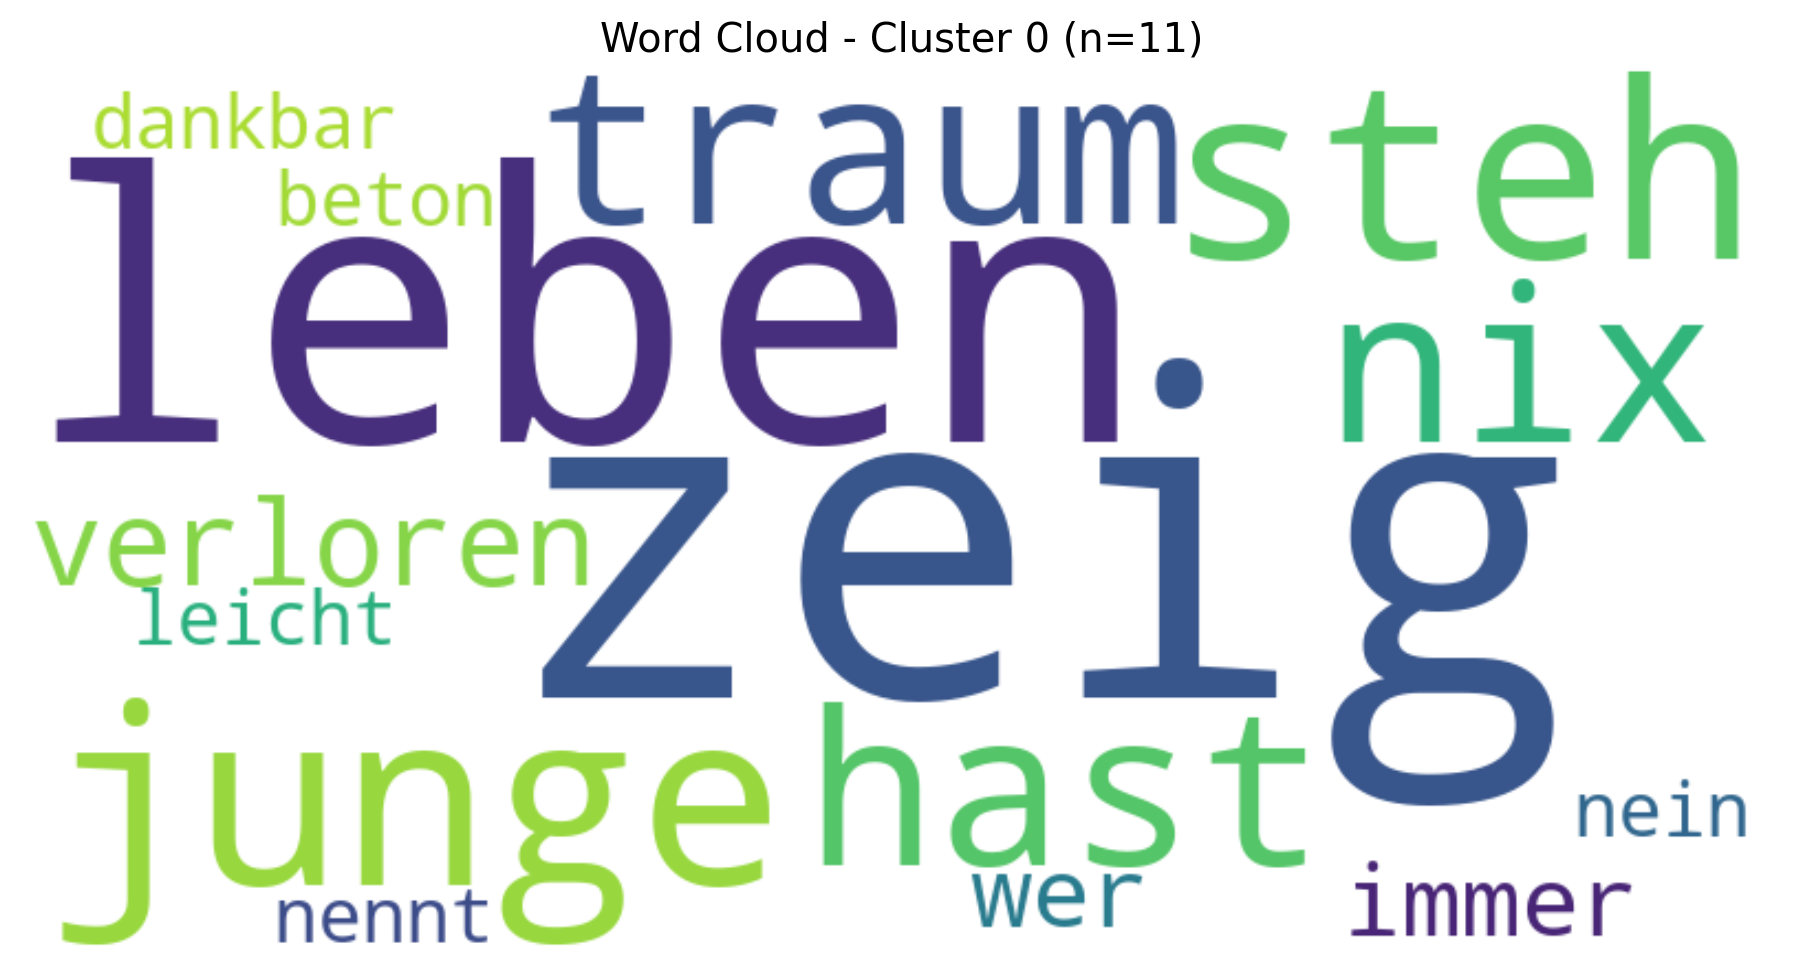

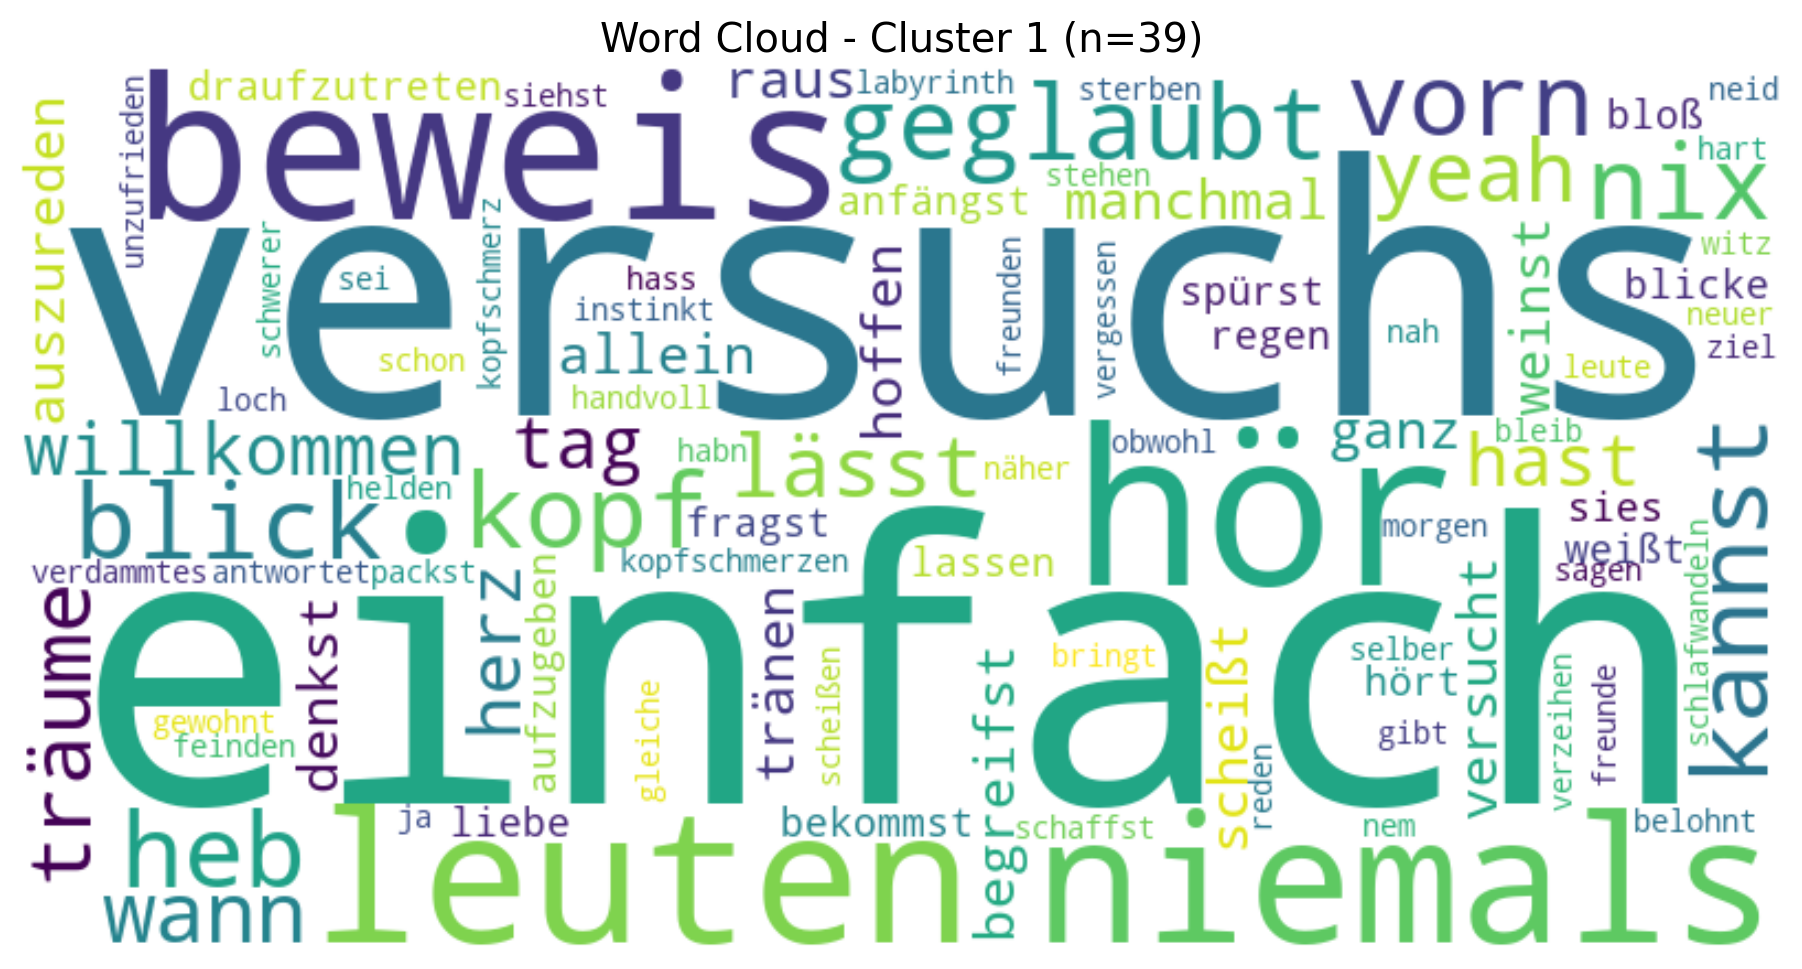

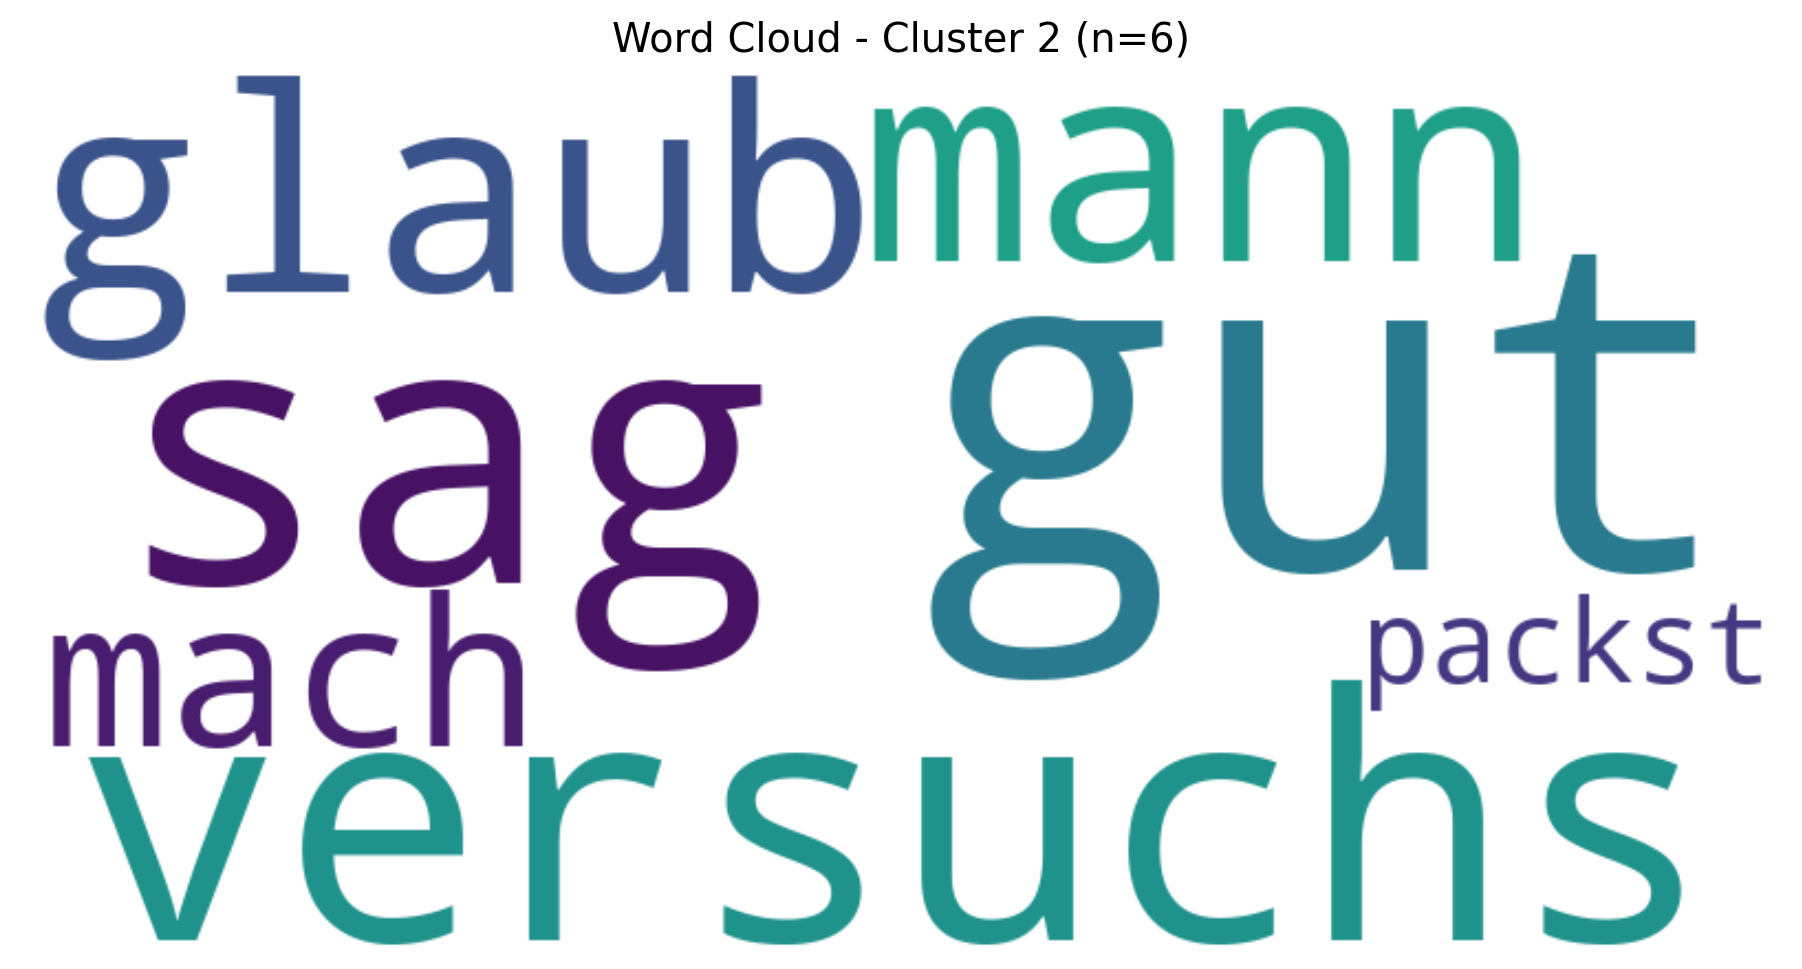

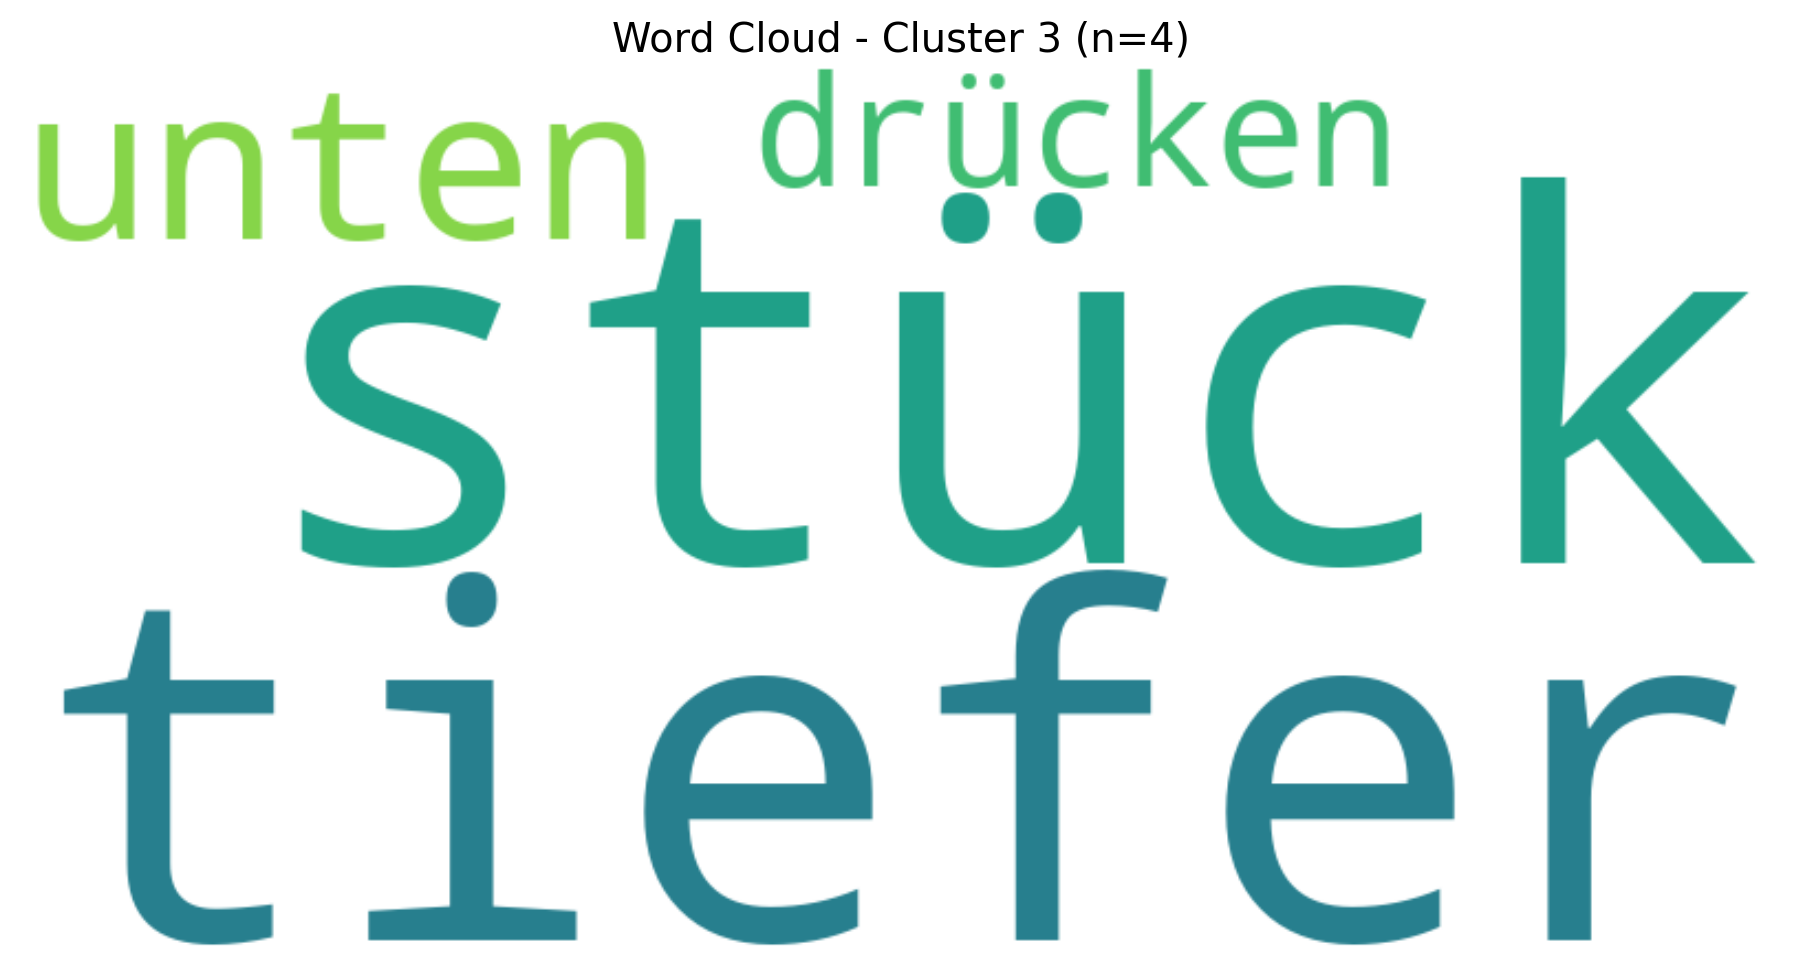

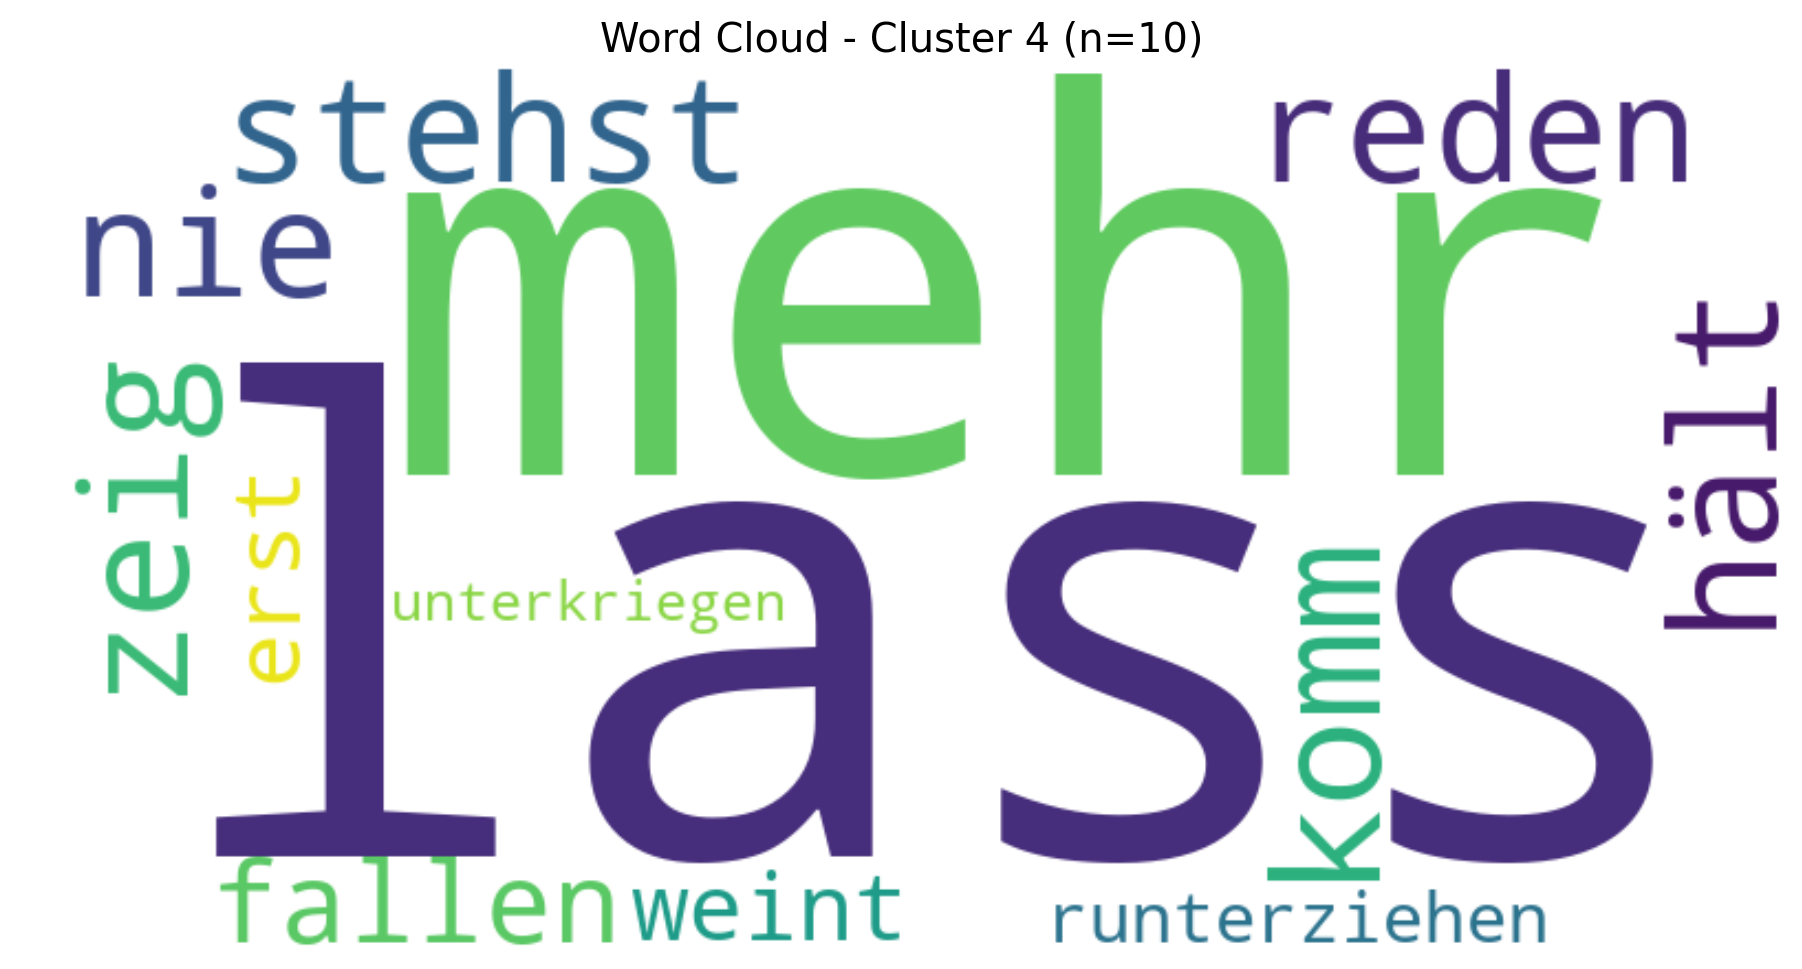

In [8]:
for cluster_id, texts in clusters.items():
    # Combine all texts in the cluster
    combined_text = " ".join(texts)
    # Clean the combined text (remove stopwords, punctuation)
    cleaned_combined = clean_text(combined_text, stop_words)
    # Generate and display word cloud
    generate_wordcloud(
        cleaned_combined,
        title=f"Word Cloud - Cluster {cluster_id} (n={len(texts)})",
        width=800,
        height=400
    )

## Summary and Next Steps

**Accomplished in this notebook:**

- Loaded German rap lyrics from Kaggle (with synthetic fallback).
- Preprocessed text: lowercasing, punctuation removal, stopword filtering.
- Vectorised text using TF‑IDF.
- Applied K‑Means clustering (k=5) to group lyrics by thematic similarity.
- Visualised cluster differences with sample text and word clouds.

**Key insights:**

- The clusters capture distinct themes, as seen in the word clouds.
- K‑Means on TF‑IDF is effective for text clustering, though it assumes a fixed number of clusters.
- Word clouds provide an intuitive way to interpret cluster content.

**Suggested next steps (critical thinking):**

1. **Optimal number of clusters** – use the elbow method or silhouette score to determine the best `k`.
2. **Advanced vectorisation** – experiment with word embeddings (e.g., Word2Vec, BERT) for richer semantic representation.
3. **Topic modelling** – apply LDA (Latent Dirichlet Allocation) to extract interpretable topics from each cluster.
4. **Interactive visualisation** – use tools like t‑SNE or UMAP to project documents in 2D and colour by cluster.
5. **Hyperparameter tuning** – adjust `max_features`, `ngram_range`, and other TF‑IDF parameters for better clustering.

This notebook serves as a foundation for text mining and unsupervised learning on textual data.